# 3.5 Agent의 히스토리를 관리하는 방법

- 에이전트의 히스토리를 관리해서 대화를 이어나가는 방법을 알아봅니다
- 히스토리를 관리를 위해 `checkpointer`를 사용합니다.
- `checkpointer`는 두 가지 방법을 제공합니다
    - 메모리에 저장하는 방법
    - 데이터베이스에 저장하는 방법
- 이 강의에서는 메모리에 저장하는 방법을 알아봅니다
    - 다양한 [`checkpointer`](https://langchain-ai.github.io/langgraph/concepts/persistence/#checkpointer-libraries)를 확인해보세요

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model='gpt-4o',
    temperature=0
)

small_llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0
)

In [3]:
from langchain_core.tools import tool

@tool
def add(a: int, b: int) -> int:
    """숫자 a와 b를 더합니다."""
    return a + b

@tool
def multiply(a: int, b: int) -> int:
    """숫자 a와 b를 곱합니다."""
    return a * b

In [4]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [5]:
from langchain_google_community import GmailToolkit

from langchain_google_community.gmail.utils import (
    build_resource_service,
    get_gmail_credentials,
)

# Can review scopes here https://developers.google.com/gmail/api/auth/scopes
# For instance, readonly scope is 'https://www.googleapis.com/auth/gmail.readonly'
credentials = get_gmail_credentials(
    token_file="./google/gmail_token.json",
    scopes=["https://mail.google.com/"],
    client_secrets_file="./google/gmail_credentials.json",
)
api_resource = build_resource_service(credentials=credentials)
gmail_toolkit = GmailToolkit(api_resource=api_resource)
gmail_tool_list = gmail_toolkit.get_tools()


In [6]:
gmail_tool_list

[GmailCreateDraft(api_resource=<googleapiclient.discovery.Resource object at 0x000002807B3C8830>),
 GmailSendMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000002807B3C8830>),
 GmailSearch(api_resource=<googleapiclient.discovery.Resource object at 0x000002807B3C8830>),
 GmailGetMessage(api_resource=<googleapiclient.discovery.Resource object at 0x000002807B3C8830>),
 GmailGetThread(api_resource=<googleapiclient.discovery.Resource object at 0x000002807B3C8830>)]

In [7]:
from langchain.agents import load_tools

loaded_tool_list = load_tools(
    ["arxiv"],
)

In [8]:
import os

from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.tools.retriever import create_retriever_tool

embedding_function = OpenAIEmbeddings(model='text-embedding-3-large')

vector_store = Chroma(
    embedding_function=embedding_function,
    collection_name = 'real_estate_tax',
    persist_directory='./real_estate_tax_collection'
)
retriever = vector_store.as_retriever(search_kwargs={'k': 3})
retriever_tool = create_retriever_tool(
    retriever=retriever,
    name='real_estate_tax_retriever',
    description='Contains information about real estate tax up to December 2024',
)

In [9]:
from langgraph.prebuilt import ToolNode

tool_list = [add, multiply, search_tool, retriever_tool] + gmail_tool_list + loaded_tool_list
llm_with_tools = small_llm.bind_tools(tool_list)
tool_node = ToolNode(tool_list)

In [10]:
from langgraph.graph import MessagesState, StateGraph

class AgentState(MessagesState):
    summary: str # 기본 state에 summary 필드를 추가하여, 메시지 요약을 저장할 수 있도록 확장

graph_builder = StateGraph(AgentState)

In [11]:
from langchain_core.messages import SystemMessage

def agent(state: AgentState) -> AgentState:
    """
    주어진 `state`에서 메시지를 가져와
    LLM과 도구를 사용하여 응답 메시지를 생성합니다.

    Args:
        state (AgentState): 메시지 기록과 요약을 포함하는 state.

    Returns:
        MessagesState: 응답 메시지를 포함하는 새로운 state.
    """
    # 메시지와 요약을 state에서 가져옵니다.
    messages = state['messages']
    summary = state['summary'] # system message로 넣어주어야 함
    
    # 요약이 비어있지 않으면, 요약을 메시지 앞에 추가합니다.
    if summary != '':
        messages = [SystemMessage(content=f'Here is the summary of the earlier conversation: {summary}')] + messages
    
    # LLM과 도구를 사용하여 메시지에 대한 응답을 생성합니다.
    response = llm_with_tools.invoke(messages) # 전체 히스토리를 llm에 전송하게되면 토큰이 많이 사용되고, 성능이 저하될 수 있음
    # 메시지 정리 방법: 1) 앞의 메시지를 삭제한다, 2) 메시지 요약을 만들어서 앞에 추가하고 메시지를 삭제한다.
    
    # 응답 메시지를 포함하는 새로운 state를 반환합니다.
    return {'messages': [response]}

In [12]:
def summarize_messages(state: AgentState) -> AgentState:
    """
    주어진 state의 메시지를 요약합니다.

    Args:
        state (AgentState): 메시지와 요약을 포함하는 state.

    Returns:
        AgentState: 요약된 메시지를 포함하는 딕셔너리.
    """
    # state에서 메시지와 요약을 가져옵니다.
    messages = state['messages']
    summary = state['summary']
    
    # 요약 프롬프트를 생성합니다.
    summary_prompt = f'summarize this chat history below: \n\nchat_history:{messages}'
    
    # 기존 요약이 있으면, 요약을 포함한 프롬프트를 생성합니다.
    if summary != '':
        summary_prompt = f'''summarize this chat history below while looking at the summary of earlier conversations
chat_history:{messages}
summary:{summary}'''
    
    # LLM을 사용하여 요약을 생성합니다.
    summary = small_llm.invoke(summary_prompt)
    
    # 요약된 메시지를 반환합니다.
    return {'summary': summary.content}

In [13]:
from langchain_core.messages import RemoveMessage # state에서 메시지를 수동으로 삭제할 때 사용

def delete_messages(state: AgentState) -> AgentState: # node를 사용해서 메시지를 삭제하는 방법
    """
    주어진 state에서 오래된 메시지를 삭제합니다.

    Args:
        state (AgentState): 메시지를 포함하는 state.

    Returns:
        AgentState: 삭제된 메시지를 포함하는 새로운 state.
    """
    # state에서 메시지를 가져옵니다.
    messages = state['messages']
    # 마지막 세 개의 메시지를 제외한 나머지 메시지를 삭제합니다.
    delete_messages = [RemoveMessage(id=message.id) for message in messages[:-3]]
    # 삭제된 메시지를 포함하는 새로운 state를 반환합니다.
    return {'messages': delete_messages}

- 영상에는 수정하면서 누락된 부분입니다 (MessagesState -> AgentState)
- `should_continue`는 `summary`를 바라보지 않기 때문에 에러가 발생하지는 않습니다

In [14]:
from typing import Literal

def should_continue(state: AgentState) -> Literal['tools', 'summarize_messages']: # 마지막 메시지를 확인하고 도구 호출이 있으면 'tools'를 반환하고, 없으면 'summarize_messages'를 반환하는 함수
    """
    주어진 state에 따라 다음 단계로 진행할지를 결정합니다.

    Args:
        state (AgentState): 메시지와 도구 호출 정보를 포함하는 state.

    Returns:
        Literal['tools', 'summarize_messages']: 다음 단계로 'tools' 또는 'summarize_messages'를 반환합니다.
    """
    # state에서 메시지를 가져옵니다.
    messages = state['messages']
    # 마지막 AI 메시지를 확인합니다.
    last_ai_message = messages[-1]
    
    # 마지막 AI 메시지가 도구 호출을 포함하고 있는지 확인합니다.
    if last_ai_message.tool_calls:
        # 도구 호출이 있으면 'tools'를 반환합니다.
        return 'tools'
    
    # 도구 호출이 없으면 'summarize_messages'를 반환합니다.
    return 'summarize_messages'

- `node`를 추가하고 `edge`로 연결합니다

In [15]:
graph_builder.add_node('agent', agent)
graph_builder.add_node('tools', tool_node)
graph_builder.add_node(delete_messages)
graph_builder.add_node(summarize_messages)

In [16]:
from langgraph.graph import START, END


graph_builder.add_edge(START, 'agent')
graph_builder.add_conditional_edges(
    'agent',
    should_continue,
    ['tools', 'summarize_messages']
)
graph_builder.add_edge('tools', 'agent')
graph_builder.add_edge('summarize_messages', 'delete_messages') # 삭제 노드를 summarize_messages 다음에 연결하여, 메시지 요약이 완료된 후에 오래된 메시지를 삭제하도록 설정
graph_builder.add_edge('delete_messages', END)

- 히스토리 관리를 위해 `checkpointer`를 사용합니다
    - `MemorySaver`는 메모리에 저장하는 방법입니다


In [17]:
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()

graph= graph_builder.compile(checkpointer=checkpointer) # 그래프 빌드 시 checkpointer를 전달하여, 그래프 실행 중에 상태가 저장될 수 있도록 설정

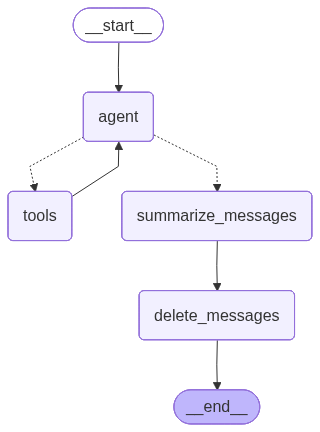

In [18]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

- `checkpointer`를 사용하는 경우, 관리를 위해 `thread_id`를 사용합니다

In [19]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

query = 'dev.euna319@gmail.com으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요'
for chunk in graph.stream({'messages': [HumanMessage(query)], 'summary': ''}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

dev.euna319@gmail.com으로 Attention Is All You Need 논문을 요약해서 이메일 초안을 작성해주세요
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_fQl6sJP6B2Ljhp7W3whLr6yC)
 Call ID: call_fQl6sJP6B2Ljhp7W3whLr6yC
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention 

In [20]:
current_message_list = graph.get_state(config).values['messages']
current_message_list

[AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_MNY7BDfHKeY562o2rYX0Rm3E', 'function': {'arguments': '{"message":"안녕하세요,\\n\\n\\"Attention Is All You Need\\" 논문에 대한 요약을 아래와 같이 작성하였습니다.\\n\\n이 논문은 Transformer 아키텍처를 소개하며, 자연어 처리 분야에서의 혁신적인 접근 방식을 제시합니다. Transformer는 순차적인 데이터 처리 대신, 입력 데이터의 모든 부분을 동시에 처리할 수 있는 자기 주의 메커니즘(self-attention mechanism)을 사용합니다. 이로 인해 모델은 문맥을 더 잘 이해하고, 긴 문장에서도 효과적으로 정보를 처리할 수 있습니다.\\n\\n주요 기여는 다음과 같습니다:\\n1. **자기 주의 메커니즘**: 입력 시퀀스의 모든 단어 간의 관계를 고려하여, 각 단어의 중요도를 동적으로 조정합니다.\\n2. **병렬 처리**: RNN과 달리, Transformer는 입력 시퀀스를 병렬로 처리할 수 있어 학습 속도가 크게 향상됩니다.\\n3. **스케일링**: 대규모 데이터셋에 대해 효과적으로 학습할 수 있는 능력을 보여줍니다.\\n\\n이 논문은 자연어 처리의 여러 작업에서 뛰어난 성능을 보여주며, 이후 다양한 분야에서 Transformer 아키텍처가 널리 사용되는 계기가 되었습니다.\\n\\n더 궁금한 점이 있으시면 언제든지 말씀해 주세요.\\n\\n감사합니다.","to":["dev.euna319@gmail.com"],"subject":"Attention Is All You Need 논문 요약"}', 'name': 'create_gmail_draft'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 342, '

In [21]:
graph.get_state(config).values['summary']


'The chat history involves a user requesting a summary of the "Attention Is All You Need" paper to be drafted into an email. The AI first retrieves relevant information about the paper and then composes a summary in Korean, highlighting the key contributions of the Transformer architecture, such as the self-attention mechanism, parallel processing capabilities, and scalability for large datasets. The AI confirms that the email draft has been created and provides the user with the content of the draft, which they can review and send via Gmail. The draft emphasizes the paper\'s impact on natural language processing and invites further questions from the recipient.'

In [22]:
# from langchain_core.messages import RemoveMessage

# for index, message in enumerate(current_message_list):
#     if index < len(current_message_list) - 1:
#         graph.update_state(config, {'messages': RemoveMessage(id=message.id)})

In [23]:
# current_message_list = graph.get_state(config).values['messages']
# current_message_list

In [24]:
from langchain_core.messages import HumanMessage

config = {
    'configurable': {
        'thread_id': 'summarize_paper'
    }
}

update_query = '논문의 출처 URL을 포함시켜주세요'
for chunk in graph.stream({'messages': [HumanMessage(update_query)]}, config=config, stream_mode='values'):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

논문의 출처 URL을 포함시켜주세요
================================== Ai Message ==================================
Tool Calls:
  arxiv (call_KMS6T57kZziIBHkZzE8c3uCX)
 Call ID: call_KMS6T57kZziIBHkZzE8c3uCX
  Args:
    query: Attention Is All You Need
================================= Tool Message =================================
Name: arxiv

Published: 2021-05-06
Title: Do You Even Need Attention? A Stack of Feed-Forward Layers Does Surprisingly Well on ImageNet
Authors: Luke Melas-Kyriazi
Summary: The strong performance of vision transformers on image classification and other vision tasks is often attributed to the design of their multi-head attention layers. However, the extent to which attention is responsible for this strong performance remains unclear. In this short report, we ask: is the attention layer even necessary? Specifically, we replace the attention layer in a vision transformer with a feed-forward laye

In [25]:
graph.get_state(config).values['summary']


'The chat history details a user\'s request for a summary of the "Attention Is All You Need" paper to be drafted into an email. The AI first composes a summary in Korean, outlining the key contributions of the Transformer architecture, including the self-attention mechanism, parallel processing, and scalability for large datasets. After confirming the email draft\'s creation, the AI provides the user with the draft content, which highlights the paper\'s significance in natural language processing and invites further inquiries. The draft is later updated to include a URL link to the paper.'

In [ ]:
# send_query = '이메일을 전송해주세요'
# for chunk in graph.stream({'messages': [HumanMessage(send_query)]}, config=config, stream_mode='values'):
#     chunk['messages'][-1].pretty_print()

================================ Human Message =================================

이메일을 전송해주세요
================================== Ai Message ==================================
Tool Calls:
  send_gmail_message (call_CnjPLj8ntP9flkJGqWDMKSp6)
 Call ID: call_CnjPLj8ntP9flkJGqWDMKSp6
  Args:
    message: 안녕하세요,

"Attention Is All You Need" 논문에 대한 요약을 아래와 같이 작성하였습니다.

이 논문은 Transformer 아키텍처를 소개하며, 자연어 처리 분야에서의 혁신적인 접근 방식을 제시합니다. Transformer는 순차적인 데이터 처리 대신, 입력 데이터의 모든 부분을 동시에 처리할 수 있는 자기 주의 메커니즘(self-attention mechanism)을 사용합니다. 이로 인해 모델은 문맥을 더 잘 이해하고, 긴 문장에서도 효과적으로 정보를 처리할 수 있습니다.

주요 기여는 다음과 같습니다:
1. **자기 주의 메커니즘**: 입력 시퀀스의 모든 단어 간의 관계를 고려하여, 각 단어의 중요도를 동적으로 조정합니다.
2. **병렬 처리**: RNN과 달리, Transformer는 입력 시퀀스를 병렬로 처리할 수 있어 학습 속도가 크게 향상됩니다.
3. **스케일링**: 대규모 데이터셋에 대해 효과적으로 학습할 수 있는 능력을 보여줍니다.

이 논문은 자연어 처리의 여러 작업에서 뛰어난 성능을 보여주며, 이후 다양한 분야에서 Transformer 아키텍처가 널리 사용되는 계기가 되었습니다.

논문의 출처는 다음과 같습니다: [Attention Is All You Need](https://arxiv.org/abs/1706.03762)

더 궁금한 점이 있으시면 언제든지 말씀해 주세요.

감사합니다.
